# Part 5 — Model Comparison & Hyperparameter Tuning

Tune RF, XGBoost and SVR with Optuna, then add a PyTorch Lightning MLP

- **Same Butina cluster IDs** loaded from `.npy` — no re-clustering
- **SVR uses Pipeline(scaler + SVR)** so StandardScaler fits only on train data inside each fold
- **`class_weight='balanced'`** for all classifiers
- **No evaluation on training data** — all numbers are out-of-fold only

---
## 0. Installs & Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, balanced_accuracy_score,
    matthews_corrcoef, f1_score
)
from sklearn.model_selection import BaseCrossValidator
from scipy.stats import pearsonr

# XGBoost
import xgboost as xgb

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# PyTorch + Lightning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

import matplotlib.pyplot as plt

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
print(f'PyTorch  : {torch.__version__}')
print(f'Lightning: {L.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')

PyTorch  : 2.12.0+cu130
Lightning: 2.6.1
GPU available: False


---
## 1. Load Data & Cluster IDs

In [2]:
# ── Feature matrix (ECFP6 — best in Part 4 ablation) ─────────────────────────
X_df    = pd.read_csv('../data/processed/X_ecfp6.csv')
mol_ids = X_df['molecule_chembl_id']
X       = X_df.drop(columns='molecule_chembl_id').values.astype(np.float32)

# ── Targets ───────────────────────────────────────────────────────────────────
y_pchembl_df = pd.read_csv('../data/processed/y_pchembl.csv')
y_binary_df  = pd.read_csv('../data/processed/y_binary.csv')

y_reg = (y_pchembl_df
         .set_index('molecule_chembl_id')
         .loc[mol_ids, 'pchembl_value']
         .values.astype(np.float32))

label_map   = {'active': 1, 'inactive': 0}
clf_mask    = mol_ids.isin(y_binary_df['molecule_chembl_id']).values
X_clf       = X[clf_mask]
mol_ids_clf = mol_ids[clf_mask].reset_index(drop=True)
y_clf       = (y_binary_df
               .set_index('molecule_chembl_id')
               .loc[mol_ids_clf, 'bioactivity_class']
               .map(label_map)
               .values)

# ── Butina cluster IDs from Part 4 ──────────────────
cluster_ids_reg = np.load('../data/cluster_id/butina_cluster_ids_reg.npy')
cluster_ids_clf = np.load('../data/cluster_id/butina_cluster_ids_clf.npy')

print(f'X (regression)      : {X.shape}')
print(f'X (classification)  : {X_clf.shape}')
print(f'y_reg range         : [{y_reg.min():.2f}, {y_reg.max():.2f}]')
print(f'Class balance       : active={y_clf.sum()}, inactive={(y_clf==0).sum()}')

X (regression)      : (9876, 339)
X (classification)  : (8154, 339)
y_reg range         : [4.00, 11.00]
Class balance       : active=7439, inactive=715


---
## 2. CV Utilities (identical to Part 4)

In [3]:
from src.models import regression_metrics, classification_metrics, run_cv_regression, run_cv_classification, ButinaCrossValidator

---
## 3. Optuna Tuning — RF, XGBoost, SVR

**Inner vs outer CV:**
Optuna tunes hyperparameters on the **training portion of fold 1** only.
The resulting best params are then evaluated across all 5 folds.
This prevents the tuning process from leaking information from the test sets.

**SVR requires a Pipeline:**
SVR with RBF kernel is sensitive to feature scale.
`Pipeline([StandardScaler, SVR])` ensures the scaler is always fitted
only on training data within each fold — never on the test fold.

In [4]:
# ── Extract fold-1 training data for the inner tuning loop ───────────────────
cv_outer    = ButinaCrossValidator(n_splits=5)
outer_splits = list(cv_outer.split(X, y_reg, groups=cluster_ids_reg))
tune_tr, _  = outer_splits[0]
X_tune, y_tune, ids_tune = X[tune_tr], y_reg[tune_tr], cluster_ids_reg[tune_tr]

# Inner CV for fast evaluation inside Optuna
cv_inner      = ButinaCrossValidator(n_splits=3)
inner_splits  = list(cv_inner.split(X_tune, y_tune, groups=ids_tune))
in_tr, in_val = inner_splits[0]

N_TRIALS  = 50   # increase to 100+ for production
best_params = {}

for model_name in ['RF', 'XGB', 'SVR']:
    def objective(trial, name=model_name):
        if name == 'RF':
            m = RandomForestRegressor(
                n_estimators    = trial.suggest_int('n_estimators', 100, 800),
                max_depth       = trial.suggest_int('max_depth', 5, 40),
                min_samples_leaf= trial.suggest_int('min_samples_leaf', 1, 10),
                random_state=RANDOM_STATE, n_jobs=-1)
        elif name == 'XGB':
            m = xgb.XGBRegressor(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600),
                max_depth        = trial.suggest_int('max_depth', 3, 10),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                tree_method      ='hist',
                random_state=RANDOM_STATE, verbosity=0)
        elif name == 'SVR':
            m = Pipeline([('scaler', StandardScaler()),
                          ('svr', SVR(
                              C      = trial.suggest_float('C', 0.1, 100, log=True),
                              epsilon= trial.suggest_float('epsilon', 0.01, 1.0),
                              gamma  = trial.suggest_categorical('gamma', ['scale', 'auto']),
                              kernel='rbf'))])
        m.fit(X_tune[in_tr], y_tune[in_tr])
        return r2_score(y_tune[in_val], m.predict(X_tune[in_val]))

    print(f'Tuning {model_name} ({N_TRIALS} trials)...')
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    best_params[model_name] = study.best_params
    print(f'  Best inner R² = {study.best_value:.4f}')
    print(f'  Params: {study.best_params}\n')

Tuning RF (50 trials)...
  Best inner R² = 0.6602
  Params: {'n_estimators': 750, 'max_depth': 40, 'min_samples_leaf': 1}

Tuning XGB (50 trials)...
  Best inner R² = 0.6805
  Params: {'n_estimators': 443, 'max_depth': 10, 'learning_rate': 0.03831887648442489, 'subsample': 0.8113266600003706, 'colsample_bytree': 0.6786823253096278}

Tuning SVR (50 trials)...
  Best inner R² = 0.6718
  Params: {'C': 3.6194816209741534, 'epsilon': 0.09329524302668515, 'gamma': 'scale'}



In [5]:
# ── Build tuned models ────────────────────────────────────────────────────────
p = best_params

rf_tuned = RandomForestRegressor(
    n_estimators    =p['RF']['n_estimators'],
    max_depth       =p['RF']['max_depth'],
    min_samples_leaf=p['RF']['min_samples_leaf'],
    random_state=RANDOM_STATE, n_jobs=-1)

xgb_tuned = xgb.XGBRegressor(
    n_estimators    =p['XGB']['n_estimators'],
    max_depth       =p['XGB']['max_depth'],
    learning_rate   =p['XGB']['learning_rate'],
    subsample       =p['XGB']['subsample'],
    colsample_bytree=p['XGB']['colsample_bytree'],
    tree_method     ='hist',
    base_score=0.5,  # for later SHAP analisis
    random_state=RANDOM_STATE, verbosity=0)

svr_tuned = Pipeline([('scaler', StandardScaler()),
                       ('svr', SVR(
                           C      =p['SVR']['C'],
                           epsilon=p['SVR']['epsilon'],
                           gamma  =p['SVR']['gamma'],
                           kernel='rbf'))])

# ── Outer 5-fold CV for all three ────────────────────────────────────────────
print('Running outer 5-fold Butina CV...')
results_reg = {}
for name, model in [('RF (tuned)', rf_tuned),
                     ('XGBoost (tuned)', xgb_tuned),
                     ('SVR (tuned)', svr_tuned)]:
    print(f'  {name}...')
    res = run_cv_regression(model, X, y_reg, cluster_ids_reg)
    results_reg[name] = res
    m, s = res.loc['mean'], res.loc['std']
    print(f'    R²={m.R2:.3f}±{s.R2:.3f}  RMSE={m.RMSE:.3f}  r={m.Pearson_r:.3f}')

Running outer 5-fold Butina CV...
  RF (tuned)...
    R²=0.707±0.014  RMSE=0.696  r=0.842
  XGBoost (tuned)...
    R²=0.724±0.008  RMSE=0.676  r=0.851
  SVR (tuned)...
    R²=0.724±0.011  RMSE=0.676  r=0.851


---
## 4. MLP 

### Architecture
```
ECFP6 input  →  BatchNorm → Linear(512) → ReLU → Dropout(0.3)
             →  BatchNorm → Linear(256) → ReLU → Dropout(0.3)
             →  BatchNorm → Linear(128) → ReLU
             →  Linear(1)   ← regression output
```
Dropout  against overfitting.

In [6]:
from src.models import MoleculeDataset, EGFRDataModule, MLPRegressor

In [7]:
# ── MLP Butina 5-fold CV ──────────────────────────────────────────────────────
input_dim        = X.shape[1]
mlp_fold_results = []

for fold, (tr, te) in enumerate(
    ButinaCrossValidator(5).split(X, y_reg, groups=cluster_ids_reg), start=1
):
    print(f'MLP Fold {fold}/5...')
    dm    = EGFRDataModule(X[tr], y_reg[tr], X[te], y_reg[te], batch_size=64)
    model = MLPRegressor(input_dim=input_dim, lr=1e-3)

    trainer = L.Trainer(
        max_epochs=100,
        accelerator='auto', devices=1,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, mode='min')],
        enable_progress_bar=False,
        logger=False,
        enable_checkpointing=False,
    )
    trainer.fit(model, dm)

    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device          # detecta dónde está el modelo
        X_te_t = torch.tensor(X[te], dtype=torch.float32).to(device)
        y_pred = model(X_te_t).squeeze().cpu().numpy()   # .cpu() al final siempre funciona

    m = regression_metrics(y_reg[te], y_pred)
    m['Fold'] = fold
    mlp_fold_results.append(m)
    print(f'  R²={m["R2"]:.3f}  RMSE={m["RMSE"]:.3f}')

mlp_df   = pd.DataFrame(mlp_fold_results).set_index('Fold')
mlp_mean = mlp_df.mean()
mlp_std  = mlp_df.std()
print(f'\nMLP mean: R²={mlp_mean.R2:.3f}±{mlp_std.R2:.3f}')

MLP Fold 1/5...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name   | Type       | Params | Mode  | FLOPs
------------------------------------------------------
0 | net    | Sequential | 340 K  | train | 0    
1 | val_r2 | R2Score    | 0      | train | 0    
------------------------------------------------------
340 K     Trainable params
0         Non-trainable params
340 K     Total params
1.363     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total Flops
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, whi

  R²=0.698  RMSE=0.715
MLP Fold 2/5...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name   | Type       | Params | Mode  | FLOPs
------------------------------------------------------
0 | net    | Sequential | 340 K  | train | 0    
1 | val_r2 | R2Score    | 0      | train | 0    
------------------------------------------------------
340 K     Trainable params
0         Non-trainable params
340 K     Total params
1.363     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total Flops


  R²=0.697  RMSE=0.704
MLP Fold 3/5...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name   | Type       | Params | Mode  | FLOPs
------------------------------------------------------
0 | net    | Sequential | 340 K  | train | 0    
1 | val_r2 | R2Score    | 0      | train | 0    
------------------------------------------------------
340 K     Trainable params
0         Non-trainable params
340 K     Total params
1.363     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total Flops


  R²=0.702  RMSE=0.691
MLP Fold 4/5...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name   | Type       | Params | Mode  | FLOPs
------------------------------------------------------
0 | net    | Sequential | 340 K  | train | 0    
1 | val_r2 | R2Score    | 0      | train | 0    
------------------------------------------------------
340 K     Trainable params
0         Non-trainable params
340 K     Total params
1.363     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total Flops


  R²=0.694  RMSE=0.716
MLP Fold 5/5...
  R²=0.726  RMSE=0.677

MLP mean: R²=0.703±0.013


---
## 5. Final Comparison Table

In [8]:
rows = []
for name, res in results_reg.items():
    m, s = res.loc['mean'], res.loc['std']
    rows.append({'Model': name, 'Features': 'ECFP6', 'Split': 'Butina 5-fold',
                 'R² (mean±std)': f'{m.R2:.3f} ± {s.R2:.3f}',
                 'RMSE': f'{m.RMSE:.3f}', 'MAE': f'{m.MAE:.3f}',
                 'Pearson r': f'{m.Pearson_r:.3f}'})

rows.append({'Model': 'MLP (Lightning)', 'Features': 'ECFP6', 'Split': 'Butina 5-fold',
             'R² (mean±std)': f'{mlp_mean.R2:.3f} ± {mlp_std.R2:.3f}',
             'RMSE': f'{mlp_mean.RMSE:.3f}', 'MAE': f'{mlp_mean.MAE:.3f}',
             'Pearson r': f'{mlp_mean.Pearson_r:.3f}'})

rows.append({'Model': '── Literature (different target/dataset) ──',
             'Features': '', 'Split': '', 'R² (mean±std)': '',
             'RMSE': '', 'MAE': '', 'Pearson r': ''})

rows.append({'Model': 'SVR (Vignaux 2023, AChE)', 'Features': 'ECFP6',
             'Split': '5-fold CV', 'R² (mean±std)': '0.810',
             'RMSE': '0.730', 'MAE': '0.550', 'Pearson r': '0.760'})

comparison_df = pd.DataFrame(rows)
print('=== REGRESSION COMPARISON (Butina 5-fold CV) ===')
print(comparison_df.to_string(index=False))
comparison_df.to_csv('../data/MLpart5_final_comparison.csv', index=False)

=== REGRESSION COMPARISON (Butina 5-fold CV) ===
                                      Model Features         Split R² (mean±std)  RMSE   MAE Pearson r
                                 RF (tuned)    ECFP6 Butina 5-fold 0.707 ± 0.014 0.696 0.511     0.842
                            XGBoost (tuned)    ECFP6 Butina 5-fold 0.724 ± 0.008 0.676 0.495     0.851
                                SVR (tuned)    ECFP6 Butina 5-fold 0.724 ± 0.011 0.676 0.495     0.851
                            MLP (Lightning)    ECFP6 Butina 5-fold 0.703 ± 0.013 0.701 0.515     0.841
── Literature (different target/dataset) ──                                                           
                   SVR (Vignaux 2023, AChE)    ECFP6     5-fold CV         0.810 0.730 0.550     0.760


---
## 6 Figures

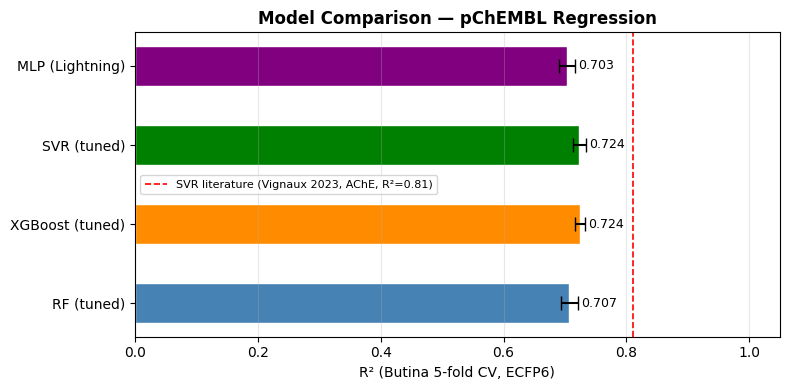

In [9]:
# ── Figure 1: R² bar chart with error bars ────────────────────────────────────
all_names = list(results_reg.keys()) + ['MLP (Lightning)']
all_means = [results_reg[n].loc['mean', 'R2'] for n in results_reg] + [mlp_mean.R2]
all_stds  = [results_reg[n].loc['std',  'R2'] for n in results_reg] + [mlp_std.R2]
colors    = ['steelblue', 'darkorange', 'green', 'purple']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(all_names, all_means, xerr=all_stds,
               color=colors, capsize=5, edgecolor='white', height=0.5)
ax.axvline(0.81, color='red', linestyle='--', linewidth=1.2,
           label='SVR literature (Vignaux 2023, AChE, R²=0.81)')
for bar, mean, std in zip(bars, all_means, all_stds):
    ax.text(mean + std + 0.005, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=9)
ax.set_xlabel('R² (Butina 5-fold CV, ECFP6)')
ax.set_title('Model Comparison — pChEMBL Regression', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/cv/part5_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

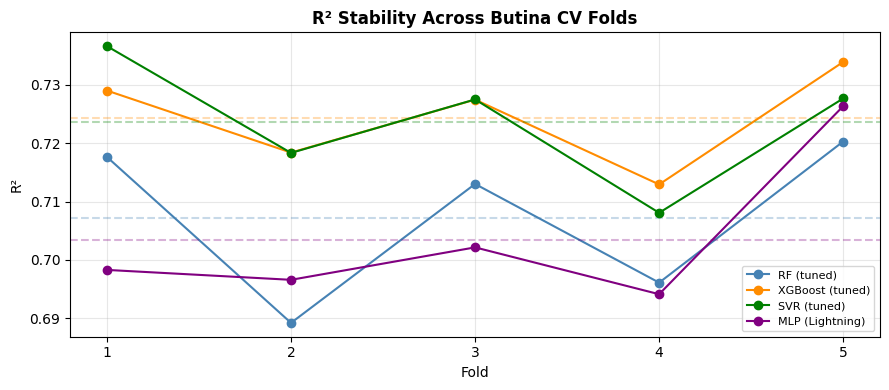

High fold variance is expected with Butina CV — some clusters
are harder to predict (structurally distinct from training data).


In [10]:
# ── Figure 2: R² per fold — show variance ─────────────────────────────────────
folds = [1, 2, 3, 4, 5]
fig, ax = plt.subplots(figsize=(9, 4))

all_dfs = list(results_reg.values()) + [mlp_df]
for name, res, col in zip(all_names, all_dfs, colors):
    vals = res.loc[folds, 'R2'].astype(float)
    ax.plot(folds, vals, 'o-', color=col, label=name, linewidth=1.5)
    ax.axhline(vals.mean(), color=col, linestyle='--', alpha=0.3)

ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('R² Stability Across Butina CV Folds', fontweight='bold')
ax.set_xticks(folds)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/cv/part5_r2_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('High fold variance is expected with Butina CV — some clusters')
print('are harder to predict (structurally distinct from training data).')

---
## 7. Save Best Model

In [11]:
all_r2 = {n: results_reg[n].loc['mean', 'R2'] for n in results_reg}
all_r2['MLP (Lightning)'] = mlp_mean.R2
best_name = max(all_r2, key=all_r2.get)
print(f'Best model: {best_name}  (mean R² = {all_r2[best_name]:.4f})')

if best_name != 'MLP (Lightning)':
    model_map = {'RF (tuned)': rf_tuned,
                 'XGBoost (tuned)': xgb_tuned,
                 'SVR (tuned)': svr_tuned}
    best_model = model_map[best_name]
    best_model.fit(X, y_reg)  # train on full dataset for Part 6 SHAP
    with open('../models/best_model_part5.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print('Saved best_model_part5.pkl')
else:
    dm_full = EGFRDataModule(X, y_reg, X, y_reg, batch_size=64)
    best_mlp = MLPRegressor(input_dim=input_dim)
    L.Trainer(max_epochs=60, accelerator='auto', devices=1,
              enable_progress_bar=True, logger=False,
              enable_checkpointing=False).fit(best_mlp, dm_full)
    torch.save(best_mlp.state_dict(), 'best_mlp_part5.pt')
    print('Saved best_mlp_part5.pt')

np.save('../data/results/X_for_shap.npy', X)   # feature matrix used for SHAP in Part 6
print('Saved X_for_shap.npy')

Best model: XGBoost (tuned)  (mean R² = 0.7243)
Saved best_model_part5.pkl
Saved X_for_shap.npy
